<a target="_blank" href="https://colab.research.google.com/github/mrdbourke/zero-to-mastery-ml/blob/master/section-2-data-science-and-ml-tools/introduction-to-scikit-learn.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

[View source code](https://github.com/mrdbourke/zero-to-mastery-ml/blob/master/section-2-data-science-and-ml-tools/introduction-to-scikit-learn.ipynb) | [Read notebook in online book format](https://dev.mrdbourke.com/zero-to-mastery-ml/introduction-to-scikit-learn/)


# A Quick Machine Learning Modelling Tutorial with Python and Scikit-Learn

This notebook goes through a range of common and useful featues of the Scikit-Learn library.

There's a bunch here but I'm calling it quick because of how vast the Scikit-Learn library is. 

Covering everything requires a [full-blown documentation](https://scikit-learn.org/stable/user_guide.html), of which, if you ever get stuck, I'd highly recommend checking out.

In [9]:
import numpy as np

X = np.array([1.0, 2.0]) 
y = np.array([300.0, 500.0])  

w = 0.0
b = 0.0
alpha =0.1
iterations = 1000 

for i in range(iterations):
    f_wb = w * X + b
    
    error = f_wb - y
    dj_dw = (1 / len(X)) * np.sum(error * X)
    dj_db = (1 / len(X)) * np.sum(error)
    
    w = w - alpha * dj_dw
    b = b - alpha * dj_db

print(f"الوزن النهائي w: {w:.2f}")
print(f"القيم الثابتة b: {b:.2f}")
print(f"توقع المودل لبيت مساحته 3000 قدم: {w * 3.0 + b:.2f}")

الوزن النهائي w: 199.99
القيم الثابتة b: 100.01
توقع المودل لبيت مساحته 3000 قدم: 699.99


## What is Scikit-Learn (sklearn)?

[Scikit-Learn](https://scikit-learn.org/stable/index.html), also referred to as `sklearn`, is an open-source Python machine learning library.

It's built on top on NumPy (Python library for numerical computing) and Matplotlib (Python library for data visualization).



## What does this notebook cover?

The Scikit-Learn library is very capable. However, learning everything off by heart isn't necessary. Instead, this notebook focuses some of the main use cases of the library.

More specifically, we'll cover:


0. An end-to-end Scikit-Learn worfklow
1. Getting the data ready
2. Choosing the right maching learning estimator/aglorithm/model for your problem
3. Fitting your chosen machine learning model to data and using it to make a prediction
4. Evaluting a machine learning model
5. Improving predictions

In [1]:
# Standard imports
import pandas as pd
# !pip install scikit-learn
import sklearn

1. Getting the data ready


In [2]:
#get data
car_sales = pd.read_csv("data\car-sales-extended.csv")
car_sales

<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Chris\AppData\Local\Temp\ipykernel_21256\990699781.py:2: SyntaxWarning: invalid escape sequence '\c'
  car_sales = pd.read_csv("data\car-sales-extended.csv")


,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043
...,...,...,...,...,...
995,Toyota,Black,35820,4,32042
996,Nissan,White,155144,3,5716
997,Nissan,Blue,66604,4,31570
998,Honda,White,215883,4,4001


In [3]:
car_sales = car_sales.drop('Colour',axis=1)
car_sales = car_sales.drop('Make',axis=1)

In [4]:
#read data
car_sales

,Odometer (KM),Doors,Price
0,35431,4,15323
1,192714,5,19943
2,84714,4,28343
3,154365,4,13434
4,181577,3,14043
...,...,...,...
995,35820,4,32042
996,155144,3,5716
997,66604,4,31570
998,215883,4,4001


In [5]:
#get the first 5 
car_sales.head(5)

,Odometer (KM),Doors,Price
0,35431,4,15323
1,192714,5,19943
2,84714,4,28343
3,154365,4,13434
4,181577,3,14043


In [6]:
#columns
car_sales.columns

Index(['Odometer (KM)', 'Doors', 'Price'], dtype='object')

In [7]:
#describe
car_sales.describe()

,Odometer (KM),Doors,Price
count,1000.000000,1000.000000,1000.000000
mean,131073.708000,4.014000,16045.665000
std,68859.723885,0.379405,8630.794219
min,10148.000000,3.000000,2796.000000
25%,71238.000000,4.000000,9481.500000
50%,131202.000000,4.000000,14264.000000
75%,192372.750000,4.000000,20738.750000
max,249860.000000,5.000000,52458.000000


In [8]:
#remove target
x = car_sales.drop('Price', axis=1)
y = car_sales['Price']

In [9]:
y

0      15323
1      19943
2      28343
3      13434
4      14043
       ...  
995    32042
996     5716
997    31570
998     4001
999    12732
Name: Price, Length: 1000, dtype: int64

In [10]:
#split data (train/test)
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2)



2. Choosing the right maching learning estimator/aglorithm/model for your problem


In [36]:
from sklearn.tree import  DecisionTreeRegressor
model = DecisionTreeRegressor(max_depth= 3)

3. Fitting your chosen machine learning model to data and using it to make a prediction


In [37]:
model.fit(x_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [40]:
x.columns

Index(['Odometer (KM)', 'Doors'], dtype='object')

In [41]:
feature_names_list = ['Odometer (KM)', 'Doors']

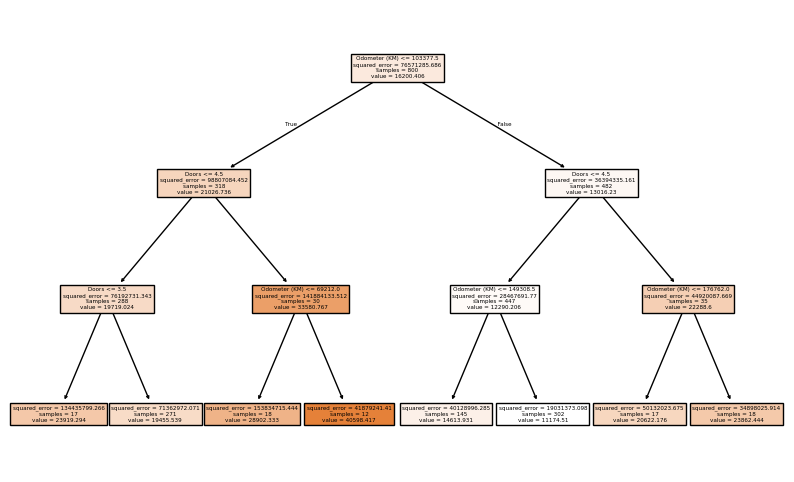

In [42]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plot_tree(model, filled=True,feature_names=feature_names_list)
plt.show()

4. Evaluting a machine learning model


In [38]:
model.score(x_test,y_test)

0.3423861527939157

In [39]:
y_preds = model.predict(x_test)

In [23]:
#MAE
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test,y_preds)

5247.084731888675

In [24]:
#MSE
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,y_preds)


42953068.61950727

In [25]:
#RMSE
import numpy as np
np.sqrt(mean_squared_error(y_test,y_preds))

np.float64(6553.859063140378)

In [26]:
#r_squared
from sklearn.metrics import r2_score
r2_score(y_test,y_preds)


0.3423861527939157